In [1]:
import torch
import numpy as np
import pandas as pd
import av
from pathlib import Path 
import matplotlib.pyplot as plt
from torch.utils.data import Dataset

In [2]:
%load_ext autoreload
%autoreload 2

from valorant.video import get_frame_at_sec
from valorant.regions import crop_map_from_video,crop_map_region

In [3]:
vod_title = "M8 vs. EDG - VALORANT Masters Santiago - SWISS"
video_path = Path(f"../../data/vods/{vod_title}.mp4")
csv_path = Path(f"../../data/processed/round_labels/{vod_title}_round_labels_fixed.csv")
round_df = pd.read_csv(csv_path)

In [4]:
import yaml
CONFIG_PATH = "../../configs/laptop.yaml" 
#環境によってパスを変える!!

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

device = cfg["runtime"]["device"]
sample_mode = cfg["runtime"]["sample_mode"]
use_gpu = cfg["runtime"]["use_gpu"]
print(cfg)


{'runtime': {'device': 'cpu', 'sample_mode': True, 'use_gpu': False}}


In [12]:
small_df = round_df.head(3).copy()
video_id = "72YPJbZQMdU"
small_df["video_id"] = video_id
cache_dir = Path("../../data/cache/test")
cache_dir.mkdir(parents=True,exist_ok=True)

In [6]:
small_df.columns

Index(['value', 'start_sec', 'end_sec', 'n_samples', 'mean_diff', 'min_diff',
       'max_diff', 'duration_sec', 't_sec', 't_min', 'left_score',
       'right_score', 'left_score_candidates', 'right_score_candidates',
       'score_total', 'round_no_from_score', 'map_no', 'round_no',
       'left_win_label', 'round_ocr_start_samples', 'round_ocr_end_samples',
       'round_no_ocr_start', 'round_no_ocr_end', 'prev_round_no_ocr',
       'prev_end_like', 'gap_from_prev', 'ocr_step', 'sequence_status',
       'action_candidate', 'fix_applied', 'needs_review', 'map',
       'start_timer_sec', 'start_search_offset_sec', 'search_start_sec',
       'start_timer_raws', 'attacker_win', 'defender_win', 'video_id'],
      dtype='str')

In [7]:
import cv2

def make_sample_times(start_sec: float, end_sec: float, config: dict):
    num_frames = int(config.get("num_frames", 8))
    sample_fps = float(config.get("sample_fps", 4))
    clip_mode = config.get("clip_mode", "from_start")
    start_offset_sec = float(config.get("start_offset_sec", 0.0))

    start_sec = float(start_sec)
    end_sec = float(end_sec)

    if clip_mode == "from_start":
        first = start_sec + start_offset_sec
        times = [first + i / sample_fps for i in range(num_frames)]

    elif clip_mode == "uniform_round":
        if num_frames == 1:
            times = [(start_sec + end_sec) / 2]
        else:
            times = np.linspace(start_sec, end_sec, num_frames).tolist()

    else:
        raise ValueError(f"未知のclip_modeです: {clip_mode}")

    # ラウンド範囲外に出ないようにする
    times = [min(max(t, start_sec), end_sec) for t in times]

    return times


def read_frame_at_sec_from_capture(cap, fps: float, t_sec: float):
    frame_idx = int(round(t_sec * fps))
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ok, frame_bgr = cap.read()

    if not ok or frame_bgr is None:
        return None

    # OpenCVはBGRなのでRGBへ
    frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)

    return frame_rgb


def make_round_clip_from_capture(cap, fps, start_sec, end_sec, config):
    """
    すでに開いてあるcv2.VideoCaptureから1ラウンド分のmap clipを作る。

    return:
        torch.Tensor [T, C, H, W], dtype=torch.uint8
    """
    image_size = config.get("image_size", 224)
    strict = bool(config.get("strict_frame_read", False))

    times = make_sample_times(start_sec, end_sec, config)

    video_width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    video_height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

    frames = []
    last_frame = None

    for t_sec in times:
        frame_rgb = read_frame_at_sec_from_capture(cap, fps, t_sec)

        if frame_rgb is None:
            if strict:
                raise RuntimeError(f"フレーム読み込み失敗: t={t_sec:.3f} sec")

            # crop_map_from_video は元動画サイズを前提にしているので、
            # 失敗時の黒画像も元動画サイズで作る
            if last_frame is None:
                frame_rgb = np.zeros(
                    (video_height, video_width, 3),
                    dtype=np.uint8,
                )
            else:
                frame_rgb = last_frame.copy()

        frame_rgb = frame_rgb.astype(np.uint8)
        frames.append(frame_rgb)
        last_frame = frame_rgb

    # [T, H, W, C]
    frames_np = np.stack(frames, axis=0)

    # ここでmap領域を一括crop
    map_np = crop_map_from_video(frames_np)

    # 念のため連続配列にする
    map_np = np.ascontiguousarray(map_np)

    # resize
    if image_size is not None:
        resized = []
        for frame in map_np:
            frame_resized = cv2.resize(
                frame,
                (int(image_size), int(image_size)),
                interpolation=cv2.INTER_AREA,
            )
            resized.append(frame_resized)

        map_np = np.stack(resized, axis=0)

    map_np = map_np.astype(np.uint8)

    # [T, H, W, C] -> [T, C, H, W]
    frames_tensor = (
        torch.from_numpy(map_np)
        .permute(0, 3, 1, 2)
        .contiguous()
    )

    return frames_tensor

In [17]:
import json
import hashlib
import re


def slugify(text: str) -> str:
    text = str(text)
    text = re.sub(r"[^\w\-]+", "_", text)
    return text.strip("_")


def make_config_hash(config: dict) -> str:
    config_str = json.dumps(config, sort_keys=True, ensure_ascii=False)
    return hashlib.md5(config_str.encode("utf-8")).hexdigest()[:8]


def build_video_round_cache(
    video_path,
    round_df: pd.DataFrame,
    cache_root,
    config: dict,
):
    video_path = Path(video_path)
    cache_root = Path(cache_root)

    start_time_col = config.get("start_time_col", "start_sec")
    start_offset_sec = float(config.get("start_offset_sec", 0.0))

    required_cols = [
        "video_id",
        "map",
        "map_no",
        "round_no",
        "start_sec",
        "end_sec",
        start_time_col,
    ]

    missing = [c for c in required_cols if c not in round_df.columns]
    if missing:
        raise ValueError(f"round_dfに必要なカラムがありません: {missing}")

    if round_df["video_id"].nunique() != 1:
        raise ValueError("round_dfに複数のvideo_idが含まれています。1動画ずつ渡してください。")

    if (round_df["end_sec"] <= round_df["start_sec"]).any():
        bad = round_df[round_df["end_sec"] <= round_df["start_sec"]]
        raise ValueError(
            "end_sec <= start_sec のラウンドがあります:\n"
            + str(bad[["map_no", "round_no", "start_sec", "end_sec"]])
        )

    video_id = str(round_df["video_id"].iloc[0])
    config_hash = make_config_hash(config)

    base_dir = (
        cache_root
        / f"config_{config_hash}"
        / f"video_{slugify(video_id)}"
    )
    base_dir.mkdir(parents=True, exist_ok=True)

    with open(base_dir / "config.json", "w", encoding="utf-8") as f:
        json.dump(config, f, indent=2, ensure_ascii=False)

    df = round_df.copy()
    df = df.sort_values(["map_no", "round_no"]).reset_index(drop=True)

    cap = cv2.VideoCapture(str(video_path))

    if not cap.isOpened():
        raise RuntimeError(f"動画を開けませんでした: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)

    if fps is None or fps <= 0:
        cap.release()
        raise RuntimeError("動画のFPSを取得できませんでした。")

    manifest_rows = []

    try:
        for _, row in df.iterrows():
            map_no = int(row["map_no"])
            map_name = slugify(row["map"])
            round_no = int(row["round_no"])

            map_dir = base_dir / f"map_{map_no:02d}_{map_name}"
            map_dir.mkdir(parents=True, exist_ok=True)

            out_path = map_dir / f"round_{round_no:03d}.pt"

            start_sec = float(row["start_sec"])
            base_start_sec = float(row["search_start_sec"])
            end_sec = float(row["end_sec"])
            clip_start_sec = base_start_sec + start_offset_sec

            frames = make_round_clip_from_capture(
                cap=cap,
                fps=fps,
                start_sec=base_start_sec,
                end_sec=end_sec,
                config=config,
            )
            item = {
                "frames": frames,
                "video_id": video_id,
                "map_no": map_no,
                "map": row["map"],
                "round_no": round_no,

                # 元の区間情報
                "start_sec": start_sec,
                "search_start_sec": row.get("search_start_sec", None),
                "end_sec": end_sec,

                # 実際にclip取得に使った情報
                "start_time_col": start_time_col,
                "base_start_sec": base_start_sec,
                "clip_start_sec": clip_start_sec,

                "config": config,
            }


            # ラベル列があれば一緒に保存
            for label_col in ["left_win_label", "attacker_win", "defender_win"]:
                if label_col in row.index:
                    item[label_col] = row[label_col]

            torch.save(item, out_path)

            manifest_row = {
                "video_id": video_id,
                "map_no": map_no,
                "map": row["map"],
                "round_no": round_no,
                "start_sec": start_sec,
                "end_sec": end_sec,
                "cache_path": str(out_path),
                "config_hash": config_hash,
            }

            for label_col in ["left_win_label", "attacker_win", "defender_win"]:
                if label_col in row.index:
                    manifest_row[label_col] = row[label_col]

            manifest_rows.append(manifest_row)

    finally:
        cap.release()

    manifest_df = pd.DataFrame(manifest_rows)
    manifest_df.to_csv(base_dir / "manifest.csv", index=False)

    return manifest_df

In [18]:
config = {
    "cache_version": "v1",
    "clip_mode": "from_start",
    "start_time_col": "search_start_sec",
    "start_offset_sec": 10.0,
    "num_frames": 8,
    "sample_fps": 4,
    "image_size": 224,
    "strict_frame_read": False,
}

cache_root = Path("../../data/cache/round_clips")

manifest_df = build_video_round_cache(
    video_path=video_path,
    round_df=small_df,
    cache_root=cache_root,
    config=config,
)

manifest_df

,video_id,map_no,map,round_no,start_sec,end_sec,cache_path,config_hash,left_win_label,attacker_win,defender_win
0,72YPJbZQMdU,1,HAVEN,1,9.009,78.078,..\..\data\cache\round_clips\config_3b22f384\v...,3b22f384,1,0,1
1,72YPJbZQMdU,1,HAVEN,2,106.106,203.203,..\..\data\cache\round_clips\config_3b22f384\v...,3b22f384,0,1,0
2,72YPJbZQMdU,1,HAVEN,3,235.235,278.278,..\..\data\cache\round_clips\config_3b22f384\v...,3b22f384,0,1,0


In [19]:
item = torch.load(manifest_df["cache_path"].iloc[0])

item["frames"].shape, item["frames"].dtype

(torch.Size([8, 3, 224, 224]), torch.uint8)

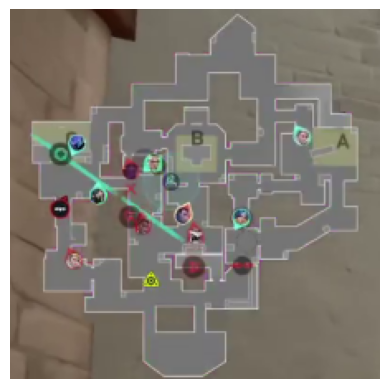

In [21]:
import matplotlib.pyplot as plt

img = item["frames"][-1].permute(1, 2, 0).numpy()

plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
class RoundCacheDataset(Dataset):
    def __init__(self,df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)
    
    def __getitem__(self,idx):
        row = self.df.iloc[idx]
        cache_path = row["cache_path"]
        pixel_values = torch.load(cache_path,map_location="cpu")
        label = int(row["attacker_win"])

        return {
            "pixel_values":pixel_values,
            "labels":torch.tensor(label).long(),
        }
        